In [21]:
import kagglehub
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")


Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
path = kagglehub.dataset_download(
    "uciml/pima-indians-diabetes-database"
)
data = pd.read_csv(f"{path}/diabetes.csv")
data = data.drop_duplicates()
data = data.dropna()
data.info()
data.head()

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


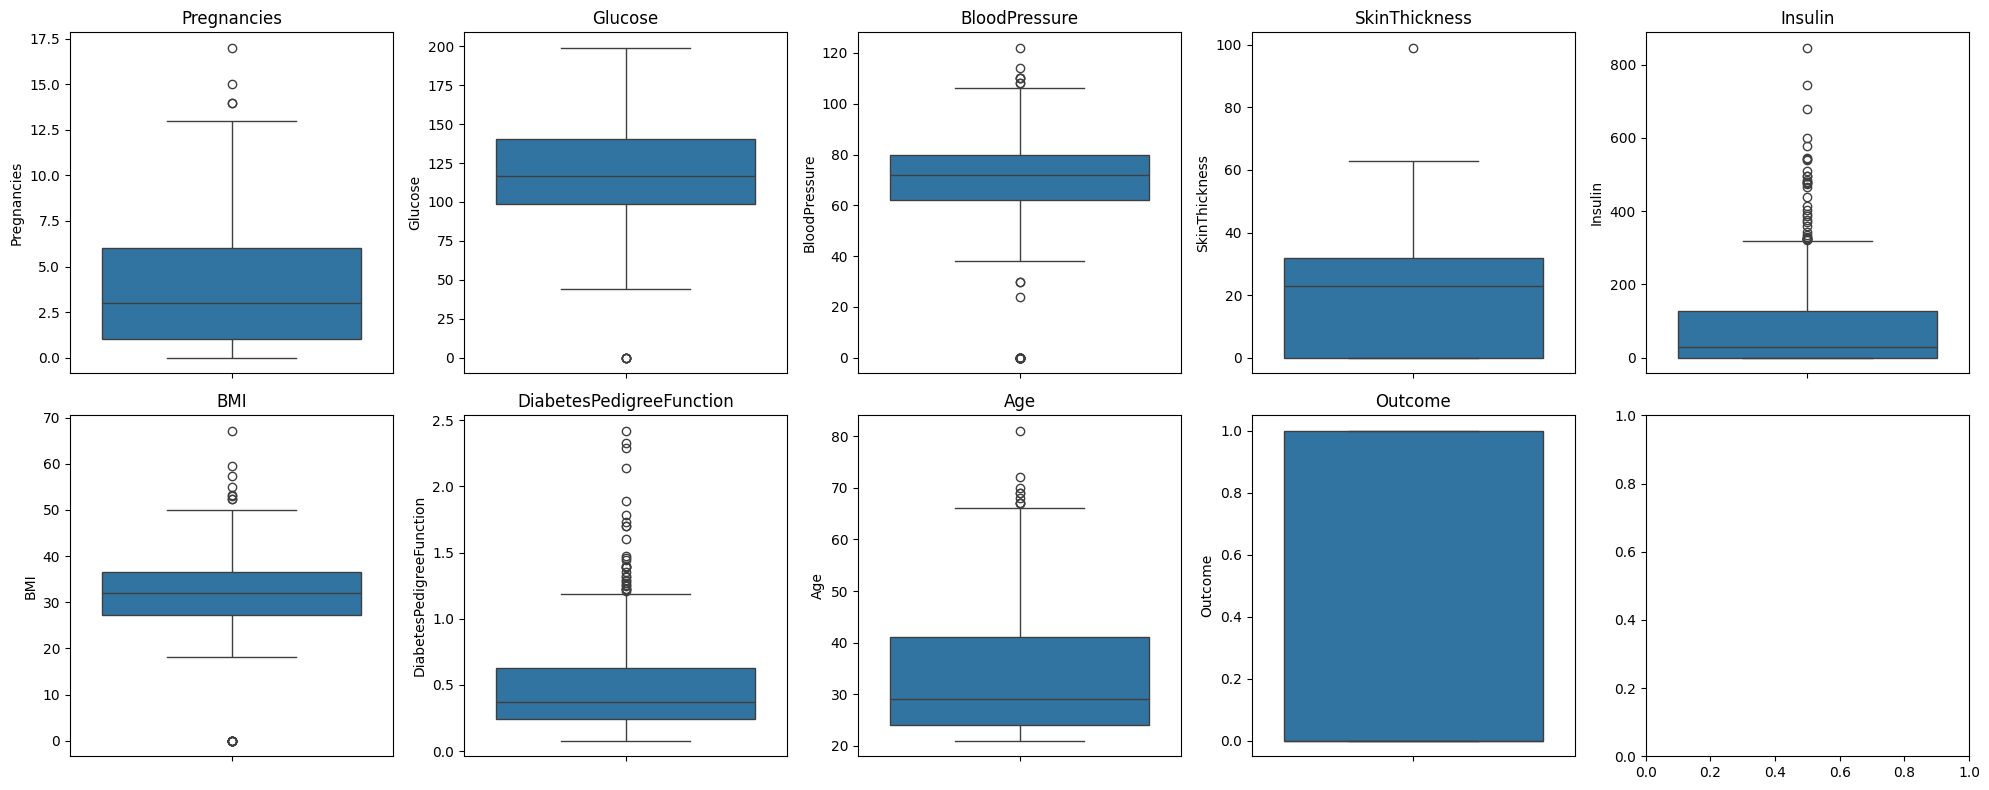

In [23]:
#anomalianeri haytnaberumy graferov
columns = data.columns
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(columns):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [24]:
#anomalianeri veracum
features = data[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1
outliers = ((features < (Q1 - 1.5 * IQR)) | (features > (Q3 + 1.5 * IQR)))
data = data[~outliers.any(axis=1)]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 639 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               639 non-null    int64  
 1   Glucose                   639 non-null    int64  
 2   BloodPressure             639 non-null    int64  
 3   SkinThickness             639 non-null    int64  
 4   Insulin                   639 non-null    int64  
 5   BMI                       639 non-null    float64
 6   DiabetesPedigreeFunction  639 non-null    float64
 7   Age                       639 non-null    int64  
 8   Outcome                   639 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 49.9 KB


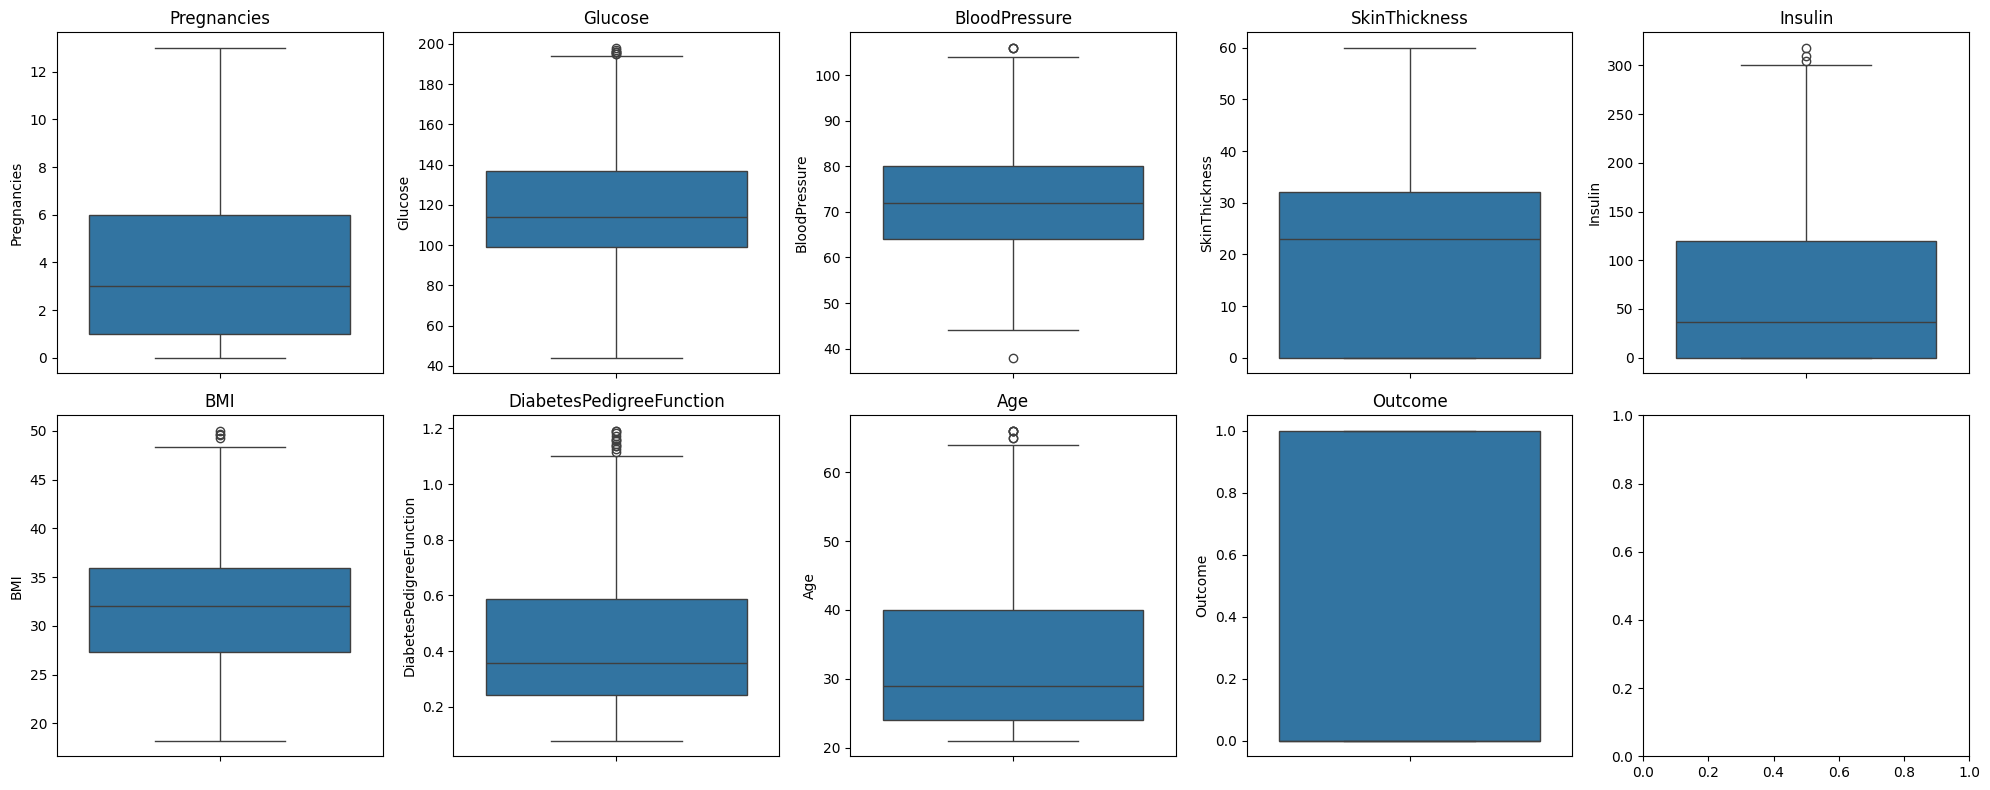

In [25]:
#anomalianeric maqrvac grafner

columns = data.columns
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(columns):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

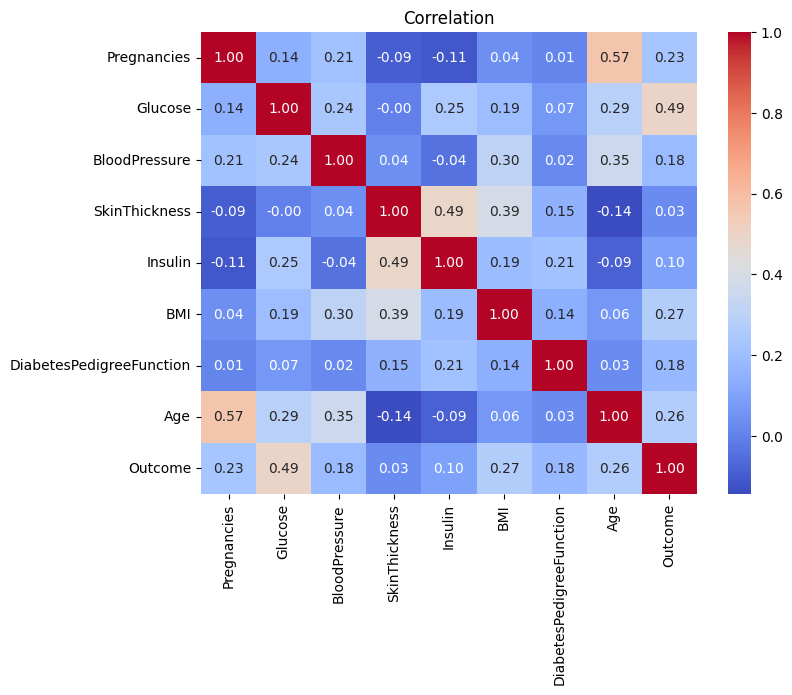

In [26]:
correlation = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation')
plt.show()

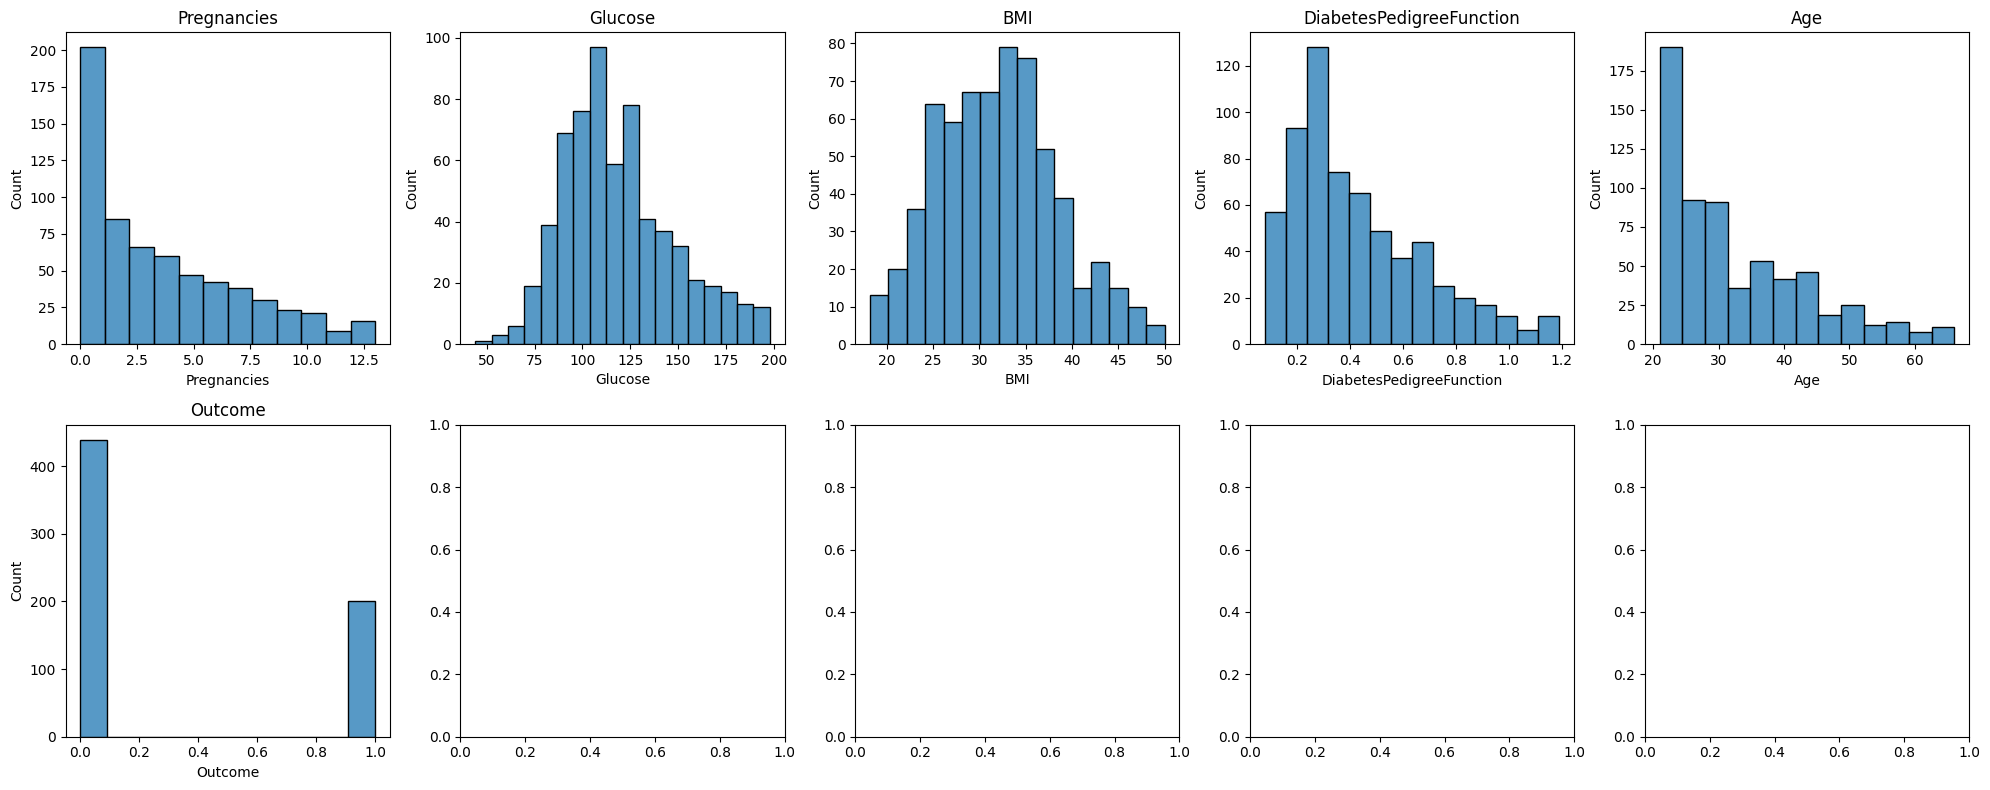

In [27]:
columns = ['Pregnancies','Glucose','BMI','DiabetesPedigreeFunction','Age','Outcome']
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(data[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [28]:
X = data[['Pregnancies','Glucose','BMI','DiabetesPedigreeFunction','Age']]
y = data['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(name)
    print("Accuracy ::", acc)
    print("Precision ::", prec)
    print("Recall ::", rec)
    print("F1 Score ::", f1)
    print()

KNN
Accuracy :: 0.8203125
Precision :: 0.7096774193548387
Recall :: 0.6111111111111112
F1 Score :: 0.6567164179104478

Decision Tree
Accuracy :: 0.7421875
Precision :: 0.5384615384615384
Recall :: 0.5833333333333334
F1 Score :: 0.56

Random Forest
Accuracy :: 0.8125
Precision :: 0.7
Recall :: 0.5833333333333334
F1 Score :: 0.6363636363636364

Naive Bayes
Accuracy :: 0.8125
Precision :: 0.7142857142857143
Recall :: 0.5555555555555556
F1 Score :: 0.625



In [30]:
class LoggRegression():
  def predict(self,x,w,b):
    Z = x @ w + b
    return (1 / (1 + np.exp(-Z)))
  def __init__(self,xtrain,ytrain,maxiter = 10000,learningrate = 0.1):
    self.xtrain = np.array(xtrain)
    self.ytrain = np.array(ytrain).reshape(-1, 1)
    n = len(self.xtrain)
    m = len(self.xtrain[0])
    self.weights = np.random.uniform(-1, 1, size=(m,1))
    self.bias = np.random.uniform(-0.5, 0.5)
    oldloss = float('inf')
    iter = 0
    for iter in range(maxiter):
      P = self.predict(self.xtrain,self.weights,self.bias)
      L = -np.mean(self.ytrain*np.log(P) + (1-self.ytrain)*np.log(1 - P))
      gradweight = (self.xtrain.T @ (P - self.ytrain))/n
      gradbias = np.sum(P-self.ytrain)/n
      weightnorm = np.sqrt(np.sum(gradweight**2))
      self.weights = self.weights - learningrate * gradweight
      self.bias = self.bias - learningrate * gradbias
      if (abs(weightnorm) < 0.001 and abs(gradbias) < 0.001) or abs(oldloss - L) < 0.0000001:
        print('Best iteration ::',iter)
        print("Train Loss :: ", L)
        break
      oldloss = L
    print("Weights ::",self.weights)
    print("Bias ::",self.bias)
  def metricsgraph(self,xtest,ytest,s=0.5):
    xtest = np.array(xtest)
    ytest = np.array(ytest).reshape(-1, 1)
    P = self.predict(xtest,self.weights,self.bias)
    L = -np.mean(ytest*np.log(P) + (1-ytest)*np.log(1 - P))
    print("Test Loss :: ",L)
    accuracy,precision,recall,f1_score,TP,FP,FN,TN = self.metrics(xtest,ytest,P,s)
    print("Accuracy :: ",accuracy*100,"%")
    print("Precision :: ", precision)
    print("Recall :: ", recall)
    print("F1 Score :: ", f1_score)
    cm = np.array([[TP, FP],[FN, TN]])
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["Positive", "Negative"])
    ax.set_yticklabels(["Positive", "Negative"])
    for i in range(2):
      for j in range(2):
        ax.text(j, i, str(cm[i, j]),ha='center', va='center', color='black', fontsize=14)
    plt.title("Confusion Matrix")
    plt.colorbar(im)
    plt.show()
    x = np.linspace(0, 1, 100)
    yaccuracy,yprecision,yrecall,yf1_score = [],[],[],[]
    for i in x:
      mt = self.metrics(xtest,ytest,P,i)
      acc,prec,rec,f1 = mt[0],mt[1],mt[2],mt[3]
      yaccuracy.append(acc)
      yprecision.append(prec)
      yrecall.append(rec)
      yf1_score.append(f1)
    yaccuracy = np.array(yaccuracy)
    yprecision = np.array(yprecision)
    yrecall = np.array(yrecall)
    yf1_score = np.array(yf1_score)
    plt.figure(figsize=(10, 6))
    plt.plot(x, yaccuracy, label='Accuracy')
    plt.plot(x, yprecision, label='Precision')
    plt.plot(x, yrecall, label='Recall')
    plt.plot(x, yf1_score, label='F1 Score')
    plt.xticks(np.arange(0, 1.05, 0.05))
    plt.yticks(np.arange(0, 1.05, 0.05))
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

  def inputpredict(self,xarray):
    xarray = np.array(xarray)
    z = xarray @ self.weights + self.bias
    return (1 / (1 + np.exp(-z)))
  def metrics(self,xtest,ytest,P,s):
    P_bin = (P > s).astype(int)
    accuracy = np.mean(P_bin == ytest)
    TP = np.sum((P_bin == 1) & (ytest == 1))
    FP = np.sum((P_bin == 1) & (ytest == 0))
    FN = np.sum((P_bin == 0) & (ytest == 1))
    TN = np.sum((P_bin == 0) & (ytest == 0))
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-9)
    return accuracy,precision,recall,f1_score,TP,FP,FN,TN





Best iteration :: 9368
Train Loss ::  0.4518733780125472
Weights :: [[1.02723585]
 [5.78150482]
 [2.67406053]
 [1.30492952]
 [0.62655762]]
Bias :: -5.91533741442403
Test Loss ::  0.42368573675014737
Accuracy ::  82.03125 %
Precision ::  0.7826086956181475
Recall ::  0.49999999998611117
F1 Score ::  0.6101694910290146


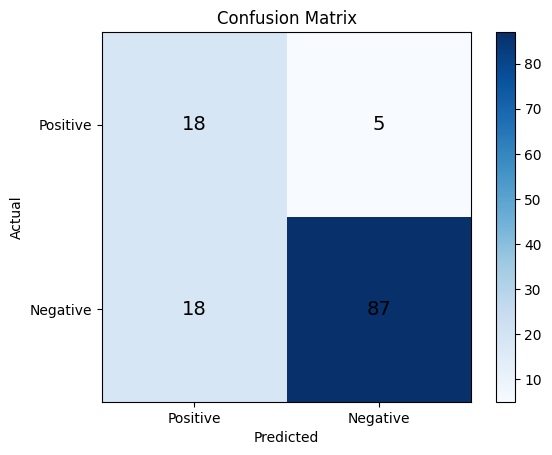

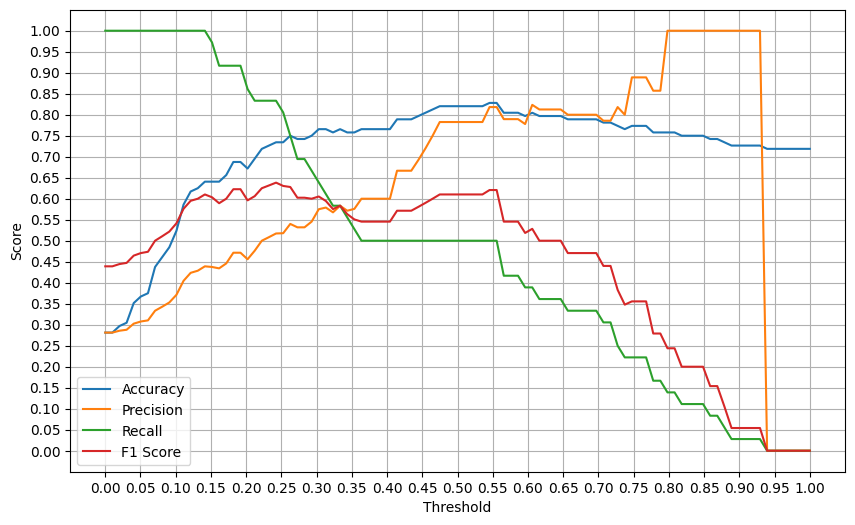

In [31]:
lgg = LoggRegression(X_train_scaled,y_train)
lgg.metricsgraph(X_test_scaled,y_test)